In [1]:
import numpy as np
import time
import pybullet as p
import pybullet_data
import scipy
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from get_robot_iiwa import sim_robot
import pickle

pybullet build time: Oct 14 2023 15:43:53


In [2]:
path_folder = 'data/iiwa_dataset_mice'

joint_pos = np.load(path_folder+'/q_list.npy')

with open(path_folder + '/Joint_X_pos.pkl', 'rb') as f:
    Joint_X_pos = pickle.load(f)

with open(path_folder + '/Jacobians.pkl', 'rb') as f:
    Jacobians = pickle.load(f)

with open(path_folder + '/l.pkl', 'rb') as f:
    l = pickle.load(f)

In [3]:
N = joint_pos.shape[0]
print(N)

2157817


In [4]:
X2 = Joint_X_pos['2']
X3 = Joint_X_pos['3']
X4 = Joint_X_pos['4']
X5 = Joint_X_pos['5']
X6 = Joint_X_pos['6']

X_2 = np.hsplit(X2[::200], 3)
X_3 = np.hsplit(X3[::200], 3)
X_4 = np.hsplit(X4[::200], 3)
X_5 = np.hsplit(X5[::200], 3)
X_6 = np.hsplit(X6[::200], 3)

print(np.array(X_6).shape)

(3, 10790, 1)


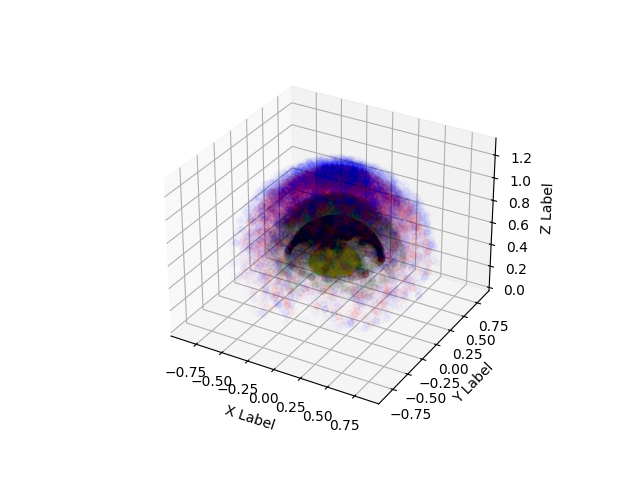

In [6]:
# %matplotlib notebook
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_6[0], X_6[1], X_6[2], color='b', alpha = 0.01)
ax.scatter(X_5[0], X_5[1], X_5[2], color='r', alpha = 0.01)
ax.scatter(X_4[0], X_4[1], X_4[2], color='g', alpha = 0.01)
ax.scatter(X_3[0], X_3[1], X_3[2], color='k', alpha = 0.01)
ax.scatter(X_2[0], X_2[1], X_2[2], color='y', alpha = 0.01)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

In [8]:
l2 = l['2']
l3 = l['3']
l4 = l['4']
l5 = l['5']
l6 = l['6']

print(l2.shape)

(2157817,)


## Plot a simple quiver

<class 'numpy.ndarray'>
(1075, 3)


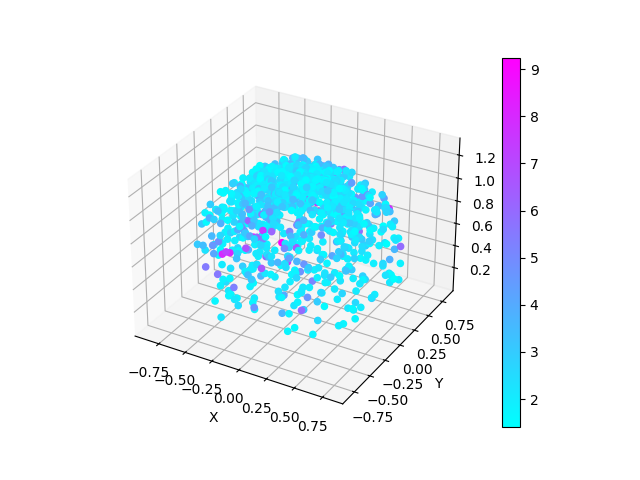

In [9]:
l6 = l6[::2000]
X6 = X6[::2000]

idx = l6 <= 10

l_6_data = l6[idx]
print(type(l_6_data))
X_6_data = X6[idx, :]
print(X_6_data.shape)

n_data = X_6_data.shape[0]

v_dir = np.array([0, 1, 0])
v_dir_tile = np.tile(v_dir, (n_data, 1))
v_dir_tile = v_dir_tile.astype(float)

v_dir_tile = np.multiply(v_dir_tile, l_6_data[:, np.newaxis])

%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(X_6_data[:,0], X_6_data[:,1], X_6_data[:,2], c = l_6_data, cmap = 'cool', alpha = 1)
# ax.quiver(X_6_data[:, 0], X_6_data[:, 1], X_6_data[:, 2], v_dir_tile[:, 0], v_dir_tile[:, 1], v_dir_tile[:, 2], color = 'r', normalize= False, alpha = 0.2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

fig.colorbar(img)

plt.show()

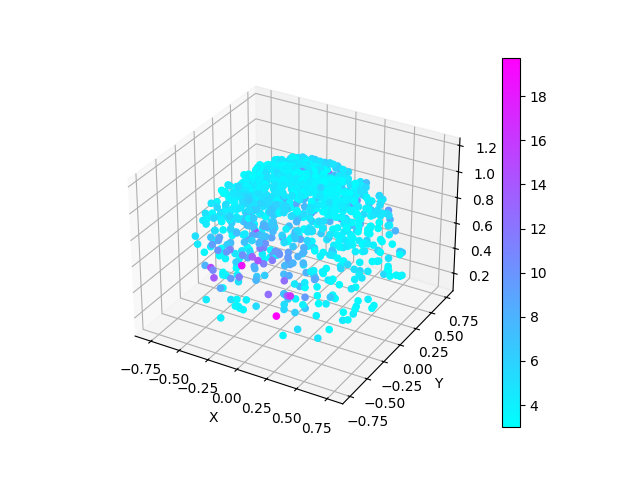

In [10]:
l5 = l5[::2000]
X5 = X5[::2000]

idx = l5 <= 20

l_5_data = l5[idx]
X_5_data = X5[idx, :]

n_data = X_5_data.shape[0]

v_dir = np.array([0, 1, 0])
v_dir_tile = np.tile(v_dir, (n_data, 1))
v_dir_tile = v_dir_tile.astype(float)

v_dir_tile = np.multiply(v_dir_tile, l_5_data[:, np.newaxis])

%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(X_5_data[:,0], X_5_data[:,1], X_5_data[:,2], c = l_5_data, cmap = 'cool', alpha = 1)
# ax.quiver(X_6_data[:, 0], X_6_data[:, 1], X_6_data[:, 2], v_dir_tile[:, 0], v_dir_tile[:, 1], v_dir_tile[:, 2], color = 'r', normalize= False, alpha = 0.2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

fig.colorbar(img)

plt.show()

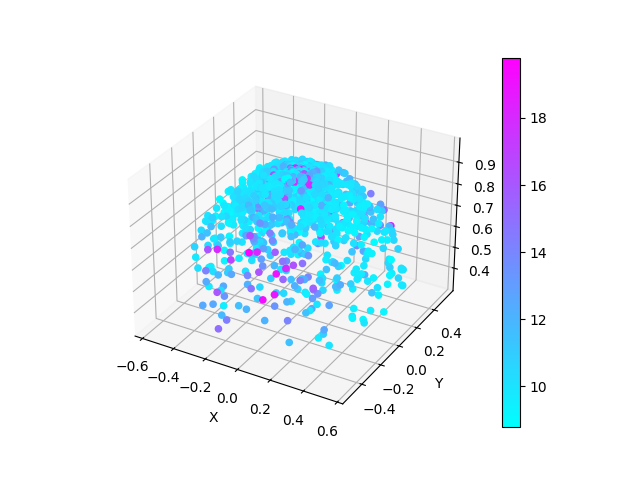

In [9]:
l4 = l4[::2000]
X4 = X4[::2000]

idx = l4 <= 20

l_4_data = l4[idx]
X_4_data = X4[idx, :]

n_data = X_4_data.shape[0]

v_dir = np.array([0, 1, 0])
v_dir_tile = np.tile(v_dir, (n_data, 1))
v_dir_tile = v_dir_tile.astype(float)

v_dir_tile = np.multiply(v_dir_tile, l_4_data[:, np.newaxis])

%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(X_4_data[:,0], X_4_data[:,1], X_4_data[:,2], c = l_4_data, cmap = 'cool', alpha = 1)
# ax.quiver(X_6_data[:, 0], X_6_data[:, 1], X_6_data[:, 2], v_dir_tile[:, 0], v_dir_tile[:, 1], v_dir_tile[:, 2], color = 'r', normalize= False, alpha = 0.2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

fig.colorbar(img)

plt.show()

# GMM GMR

In [11]:
import numpy as np
import time
import pybullet as p
import pybullet_data
import scipy
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from get_robot_iiwa import sim_robot
import pickle
from gmr import GMM

### Get good data

Here the idea is that we cannot really use the entire dataset for learning as it is huge. We are given the position of the object, i will filter the data using where the object is.

In [12]:
path_folder = 'data/iiwa_dataset_mice'

joint_pos = np.load(path_folder+'/q_list.npy')

with open(path_folder + '/Joint_X_pos.pkl', 'rb') as f:
    Joint_X_pos = pickle.load(f)

with open(path_folder + '/Jacobians.pkl', 'rb') as f:
    Jacobians = pickle.load(f)

with open(path_folder + '/l.pkl', 'rb') as f:
    l = pickle.load(f)

with open(path_folder + '/v_max.pkl', 'rb') as f:
    v_max = pickle.load(f)

N = joint_pos.shape[0]
print(N)

2157817


In [13]:
q = joint_pos

X2 = Joint_X_pos['2']
X3 = Joint_X_pos['3']
X4 = Joint_X_pos['4']
X5 = Joint_X_pos['5']
X6 = Joint_X_pos['6']

V2 = v_max['2']
V3 = v_max['3']
V4 = v_max['4']
V5 = v_max['5']
V6 = v_max['6']

l2 = l['2']
l3 = l['3']
l4 = l['4']
l5 = l['5']
l6 = l['6']

J2 = Jacobians['2']
J3 = Jacobians['3']
J4 = Jacobians['4']
J5 = Jacobians['5']
J6 = Jacobians['6']

In [14]:
## Given object position (0.3, 0.3, 0.3), create a new dataset
X_obj = np.array([0.3, 0.3, 0.3])

id2 = np.linalg.norm(X2 - X_obj, axis=1) <= 0.1 
id3 = np.linalg.norm(X3 - X_obj, axis=1) <= 0.1
id4 = np.linalg.norm(X4 - X_obj, axis=1) <= 0.1
id5 = np.linalg.norm(X5 - X_obj, axis=1) <= 0.1
id6 = np.linalg.norm(X6 - X_obj, axis=1) <= 0.1

In [15]:
q2_learn = q[id2, :]
q3_learn = q[id3, :]
q4_learn = q[id4, :]
q5_learn = q[id6, :]
q6_learn = q[id6, :]

X2_learn = X2[id2, :]
X3_learn = X3[id3, :]
X4_learn = X4[id4, :]
X5_learn = X5[id5, :]
X6_learn = X6[id6, :]

l2_learn = l2[id2].reshape(-1, 1)
l3_learn = l3[id3].reshape(-1, 1)
l4_learn = l4[id4].reshape(-1, 1)
l5_learn = l5[id5].reshape(-1, 1)
l6_learn = l6[id6].reshape(-1, 1)

v2_learn = V2[id2].reshape(-1, 1)
v3_learn = V3[id3].reshape(-1, 1)
v4_learn = V4[id4].reshape(-1, 1)
v5_learn = V5[id5].reshape(-1, 1)
v6_learn = V6[id6].reshape(-1, 1)

J2_learn = J2[id2, :, :]
J3_learn = J3[id3, :, :]
J4_learn = J4[id4, :, :]
J5_learn = J5[id5, :, :]
J6_learn = J6[id6, :, :]

In [16]:
input = np.concatenate((q6_learn, l6_learn, v6_learn), axis=1)

print(input.shape)

(419, 9)


In [17]:
gmm = GMM(n_components=8, random_state=0)
gmm.from_samples(input)

In [18]:
indices = np.array([7,8])
feat = np.array([3, 1]).reshape(-1, 1).T
print(feat.shape)
position = gmm.predict(indices, feat)
position = position.reshape(-1)

print(position)
a = np.array([-0.6, 0.8, 0.3, -1.6, 1.0, 1.75, 0.0])
print(a)

(1, 2)
[ 1.00641023  0.9626438   0.73560597 -1.92261411 -0.19739162  1.5850917
 -1.88534143]
[-0.6   0.8   0.3  -1.6   1.    1.75  0.  ]


In [19]:
robot = sim_robot(0,1)
v_dir = np.array([0, 1, 0])
robot.set_to_joint_position(position)

In [19]:
inertia = robot.get_effective_inertia_point(v_dir, 6)
print(inertia)

2.792392708895771


In [20]:
a = robot.get_ee_position()
a

(-0.01599311926611493, 0.3738429287665232, 0.25057632347592496)

In [21]:
print(X2_learn.shape)
print(X3_learn.shape)
print(X4_learn.shape)
print(X5_learn.shape)
print(X6_learn.shape)

print(q2_learn.shape)
print(q3_learn.shape)
print(q4_learn.shape)
print(q5_learn.shape)
print(q6_learn.shape)

print(l2_learn.shape)
print(l3_learn.shape)
print(l4_learn.shape)
print(l5_learn.shape)
print(l6_learn.shape)

(0, 3)
(0, 3)
(1489, 3)
(786, 3)
(419, 3)
(0, 7)
(0, 7)
(1489, 7)
(419, 7)
(419, 7)
(0, 1)
(0, 1)
(1489, 1)
(786, 1)
(419, 1)
